In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Cell 2
file_path = "U.S._Chronic_Disease_Indicators.csv"  
# First, load the data into a variable
raw = pd.read_csv(file_path, low_memory=False)  # Load data into 'raw' first

# Keep an untouched copy
usd_indicator = raw.copy()  # Now 'raw' is defined before using it

print("Loaded rows,cols:", usd_indicator.shape)
usd_indicator.head(5)

Loaded rows,cols: (309215, 30)


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,Unnamed: 20,Unnamed: 21,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,NaN,NaN,NaN,59,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,NaN,NaN,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NaN,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,NaN,NaN,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NaN,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,NaN,NaN,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NaN,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,NaN,NaN,POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NaN,NMBR,RACE,WHT


In [3]:
usd_indicator.columns = usd_indicator.columns.str.strip()

In [4]:
usd_indicator_updated = usd_indicator.loc[:, ~usd_indicator.columns.str.contains("^Unnamed")]

print("Columns after cleanup:")
print(usd_indicator.columns)

Columns after cleanup:
Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'Response', 'DataValueUnit', 'DataValueType',
       'DataValue', 'DataValueAlt', 'DataValueFootnoteSymbol',
       'DataValueFootnote', 'LowConfidenceLimit', 'HighConfidenceLimit',
       'StratificationCategory1', 'Stratification1', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Geolocation',
       'LocationID', 'TopicID', 'QuestionID', 'ResponseID', 'DataValueTypeID',
       'StratificationCategoryID1', 'StratificationID1'],
      dtype='object')


In [5]:
usd_indicator.head(3)

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,Unnamed: 20,Unnamed: 21,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,NaN,NaN,NaN,59,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,NaN,NaN,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NaN,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,NaN,NaN,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NaN,NMBR,OVERALL,OVR


In [6]:
usd_indicator = usd_indicator.loc[:, ~usd_indicator.columns.str.contains("Unnamed", case=False)]

In [7]:
print(usd_indicator.columns.tolist())

['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource', 'Topic', 'Question', 'Response', 'DataValueUnit', 'DataValueType', 'DataValue', 'DataValueAlt', 'DataValueFootnoteSymbol', 'DataValueFootnote', 'LowConfidenceLimit', 'HighConfidenceLimit', 'StratificationCategory1', 'Stratification1', 'Geolocation', 'LocationID', 'TopicID', 'QuestionID', 'ResponseID', 'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1']


In [8]:
usd_indicator.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,Sex,Female,NaN,59,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,Sex,Male,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NaN,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,Overall,Overall,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NaN,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,Race/Ethnicity,Hispanic,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NaN,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,Race/Ethnicity,"White, non-Hispanic",POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NaN,NMBR,RACE,WHT


In [9]:
resp_dropped = usd_indicator.drop(columns=["Response"])

In [10]:
resp_dropped

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,...,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,Number,Age-adjusted Mean,2.9,...,Sex,Female,NaN,59,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9537.0,...,Sex,Male,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NaN,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,486.0,...,Overall,Overall,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NaN,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2880.0,...,Race/Ethnicity,Hispanic,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NaN,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,519.0,...,Race/Ethnicity,"White, non-Hispanic",POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NaN,NMBR,RACE,WHT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309210,2022,2022,VI,Virgin Islands,BRFSS,Tobacco,Quit attempts in the past year among adult cur...,%,Age-adjusted Prevalence,NaN,...,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-64.896335 18.335765),78,TOB,TOB06,NaN,AGEADJPREV,RACE,AIAN
309211,2022,2022,WV,West Virginia,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Crude Prevalence,14.0,...,Overall,Overall,POINT (-80.71264013499967 38.66551020200046),54,COPD,COPD01,NaN,CRDPREV,OVERALL,OVR
309212,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,%,Crude Prevalence,64.2,...,Race/Ethnicity,"Black, non-Hispanic",POINT (-89.81637074199966 44.39319117400049),55,IMM,IMM04,NaN,CRDPREV,RACE,BLK
309213,2022,2022,VT,Vermont,BRFSS,Social Determinants of Health,Lack of health insurance among adults aged 18-...,%,Crude Prevalence,NaN,...,Race/Ethnicity,"Hawaiian or Pacific Islander, non-Hispanic",POINT (-72.51764079099962 43.62538123900049),50,SDOH,SDH09,NaN,CRDPREV,RACE,HAPI


In [11]:
cleaned_data = usd_indicator.drop(columns=["ResponseID", "Response"], errors="ignore")

In [12]:
cleaned_data

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,...,HighConfidenceLimit,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,Number,Age-adjusted Mean,2.9,...,2.9,Sex,Female,NaN,59,HEA,HEA04,AGEADJMEAN,SEX,SEXF
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9537.0,...,NaN,Sex,Male,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,486.0,...,NaN,Overall,Overall,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2880.0,...,NaN,Race/Ethnicity,Hispanic,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,519.0,...,NaN,Race/Ethnicity,"White, non-Hispanic",POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NMBR,RACE,WHT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309210,2022,2022,VI,Virgin Islands,BRFSS,Tobacco,Quit attempts in the past year among adult cur...,%,Age-adjusted Prevalence,NaN,...,NaN,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-64.896335 18.335765),78,TOB,TOB06,AGEADJPREV,RACE,AIAN
309211,2022,2022,WV,West Virginia,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Crude Prevalence,14.0,...,15.2,Overall,Overall,POINT (-80.71264013499967 38.66551020200046),54,COPD,COPD01,CRDPREV,OVERALL,OVR
309212,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,%,Crude Prevalence,64.2,...,74.6,Race/Ethnicity,"Black, non-Hispanic",POINT (-89.81637074199966 44.39319117400049),55,IMM,IMM04,CRDPREV,RACE,BLK
309213,2022,2022,VT,Vermont,BRFSS,Social Determinants of Health,Lack of health insurance among adults aged 18-...,%,Crude Prevalence,NaN,...,NaN,Race/Ethnicity,"Hawaiian or Pacific Islander, non-Hispanic",POINT (-72.51764079099962 43.62538123900049),50,SDOH,SDH09,CRDPREV,RACE,HAPI


In [13]:
# Drop confidence interval columns
df_cleaned_data = cleaned_data.drop(columns=["LowConfidenceLimit", "HighConfidenceLimit"], errors="ignore")

# Confirm removal
print(df_cleaned_data.columns)

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'DataValueUnit', 'DataValueType', 'DataValue',
       'DataValueAlt', 'DataValueFootnoteSymbol', 'DataValueFootnote',
       'StratificationCategory1', 'Stratification1', 'Geolocation',
       'LocationID', 'TopicID', 'QuestionID', 'DataValueTypeID',
       'StratificationCategoryID1', 'StratificationID1'],
      dtype='object')


In [14]:
df_cleaned_data

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,...,DataValueFootnote,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,Number,Age-adjusted Mean,2.9,...,NaN,Sex,Female,NaN,59,HEA,HEA04,AGEADJMEAN,SEX,SEXF
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9537.0,...,NaN,Sex,Male,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,486.0,...,NaN,Overall,Overall,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2880.0,...,NaN,Race/Ethnicity,Hispanic,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,519.0,...,NaN,Race/Ethnicity,"White, non-Hispanic",POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NMBR,RACE,WHT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309210,2022,2022,VI,Virgin Islands,BRFSS,Tobacco,Quit attempts in the past year among adult cur...,%,Age-adjusted Prevalence,NaN,...,No data available for this indicator because t...,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-64.896335 18.335765),78,TOB,TOB06,AGEADJPREV,RACE,AIAN
309211,2022,2022,WV,West Virginia,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Crude Prevalence,14.0,...,NaN,Overall,Overall,POINT (-80.71264013499967 38.66551020200046),54,COPD,COPD01,CRDPREV,OVERALL,OVR
309212,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,%,Crude Prevalence,64.2,...,NaN,Race/Ethnicity,"Black, non-Hispanic",POINT (-89.81637074199966 44.39319117400049),55,IMM,IMM04,CRDPREV,RACE,BLK
309213,2022,2022,VT,Vermont,BRFSS,Social Determinants of Health,Lack of health insurance among adults aged 18-...,%,Crude Prevalence,NaN,...,Data suppressed; denominator < 50 or relative ...,Race/Ethnicity,"Hawaiian or Pacific Islander, non-Hispanic",POINT (-72.51764079099962 43.62538123900049),50,SDOH,SDH09,CRDPREV,RACE,HAPI


In [15]:
df_cleaned_data["DataValue"].isna().mean()

0.3234610222660608

In [16]:
df_cleaned_data_2 = cleaned_data.drop(columns=["DataValueFootnote", "HighConfidenceLimit", "LowConfidenceLimit", "DataValue", "DataValueFootnoteSymbol"], errors="ignore")


In [17]:
df_cleaned_data_2

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValueAlt,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,Number,Age-adjusted Mean,2.9,Sex,Female,NaN,59,HEA,HEA04,AGEADJMEAN,SEX,SEXF
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9537.0,Sex,Male,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,486.0,Overall,Overall,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2880.0,Race/Ethnicity,Hispanic,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,519.0,Race/Ethnicity,"White, non-Hispanic",POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NMBR,RACE,WHT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309210,2022,2022,VI,Virgin Islands,BRFSS,Tobacco,Quit attempts in the past year among adult cur...,%,Age-adjusted Prevalence,NaN,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-64.896335 18.335765),78,TOB,TOB06,AGEADJPREV,RACE,AIAN
309211,2022,2022,WV,West Virginia,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Crude Prevalence,14.0,Overall,Overall,POINT (-80.71264013499967 38.66551020200046),54,COPD,COPD01,CRDPREV,OVERALL,OVR
309212,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,%,Crude Prevalence,64.2,Race/Ethnicity,"Black, non-Hispanic",POINT (-89.81637074199966 44.39319117400049),55,IMM,IMM04,CRDPREV,RACE,BLK
309213,2022,2022,VT,Vermont,BRFSS,Social Determinants of Health,Lack of health insurance among adults aged 18-...,%,Crude Prevalence,NaN,Race/Ethnicity,"Hawaiian or Pacific Islander, non-Hispanic",POINT (-72.51764079099962 43.62538123900049),50,SDOH,SDH09,CRDPREV,RACE,HAPI


In [18]:
df_cleaned_data_2[df_cleaned_data_2["LocationAbbr"] == "US"].head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValueAlt,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,Number,Age-adjusted Mean,2.9,Sex,Female,NaN,59,HEA,HEA04,AGEADJMEAN,SEX,SEXF
12,2015,2019,US,United States,US Cancer DVT,Cancer,Invasive cancer (all sites combined) mortality...,Number,Number,314982.0,Sex,Male,NaN,59,CAN,CAN08,NMBR,SEX,SEXM
61,2018,2019,US,United States,NSCH,Sleep,Short sleep duration among children aged 4 mon...,%,Crude Prevalence,34.4,Overall,Overall,NaN,59,SLEP,SLP01,CRDPREV,OVERALL,OVR
331,2019,2019,US,United States,YRBSS,Alcohol,Alcohol use among high school students,%,Crude Prevalence,31.9,Sex,Female,NaN,59,ALC,ALC01,CRDPREV,SEX,SEXF
332,2019,2019,US,United States,BRFSS,Cardiovascular Disease,Taking medicine for high cholesterol among adults,%,Crude Prevalence,28.0,Race/Ethnicity,Hispanic,NaN,59,CVD,CVD04,CRDPREV,RACE,HIS


In [19]:
df_cleaned_data_2[df_cleaned_data_2["LocationAbbr"] == "US"].shape

(5763, 19)

In [20]:
usd_analysis = df_cleaned_data_2[df_cleaned_data_2["LocationAbbr"] != "US"].copy()

print("Remaining rows:", usd_analysis.shape)
print("Unique locations:", usd_analysis["LocationAbbr"].nunique())

Remaining rows: (303452, 19)
Unique locations: 54


In [21]:
usd_analysis

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValueAlt,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9537.0,Sex,Male,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,486.0,Overall,Overall,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2880.0,Race/Ethnicity,Hispanic,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,519.0,Race/Ethnicity,"White, non-Hispanic",POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NMBR,RACE,WHT
5,2015,2019,KS,Kansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,8102.0,Sex,Male,POINT (-98.20078122699965 38.34774030000045),20,CAN,CAN07,NMBR,SEX,SEXM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309210,2022,2022,VI,Virgin Islands,BRFSS,Tobacco,Quit attempts in the past year among adult cur...,%,Age-adjusted Prevalence,NaN,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-64.896335 18.335765),78,TOB,TOB06,AGEADJPREV,RACE,AIAN
309211,2022,2022,WV,West Virginia,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Crude Prevalence,14.0,Overall,Overall,POINT (-80.71264013499967 38.66551020200046),54,COPD,COPD01,CRDPREV,OVERALL,OVR
309212,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,%,Crude Prevalence,64.2,Race/Ethnicity,"Black, non-Hispanic",POINT (-89.81637074199966 44.39319117400049),55,IMM,IMM04,CRDPREV,RACE,BLK
309213,2022,2022,VT,Vermont,BRFSS,Social Determinants of Health,Lack of health insurance among adults aged 18-...,%,Crude Prevalence,NaN,Race/Ethnicity,"Hawaiian or Pacific Islander, non-Hispanic",POINT (-72.51764079099962 43.62538123900049),50,SDOH,SDH09,CRDPREV,RACE,HAPI


In [22]:
sorted(usd_analysis["Topic"].unique())

['Alcohol',
 'Arthritis',
 'Asthma',
 'Cancer',
 'Cardiovascular Disease',
 'Chronic Kidney Disease',
 'Chronic Obstructive Pulmonary Disease',
 'Cognitive Health and Caregiving',
 'Diabetes',
 'Disability',
 'Health Status',
 'Immunization',
 'Maternal Health',
 'Mental Health',
 'Nutrition, Physical Activity, and Weight Status',
 'Oral Health',
 'Sleep',
 'Social Determinants of Health',
 'Tobacco']

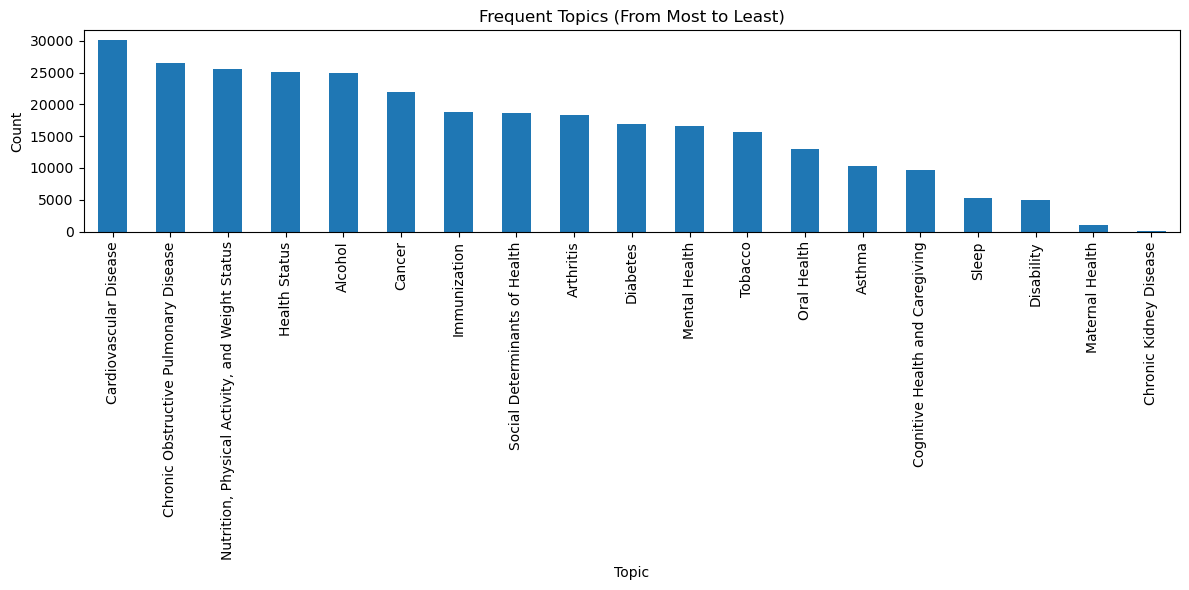

In [30]:


# Count records per topic
topic_counts = usd_analysis["Topic"].value_counts()

# Create single bar chart
plt.figure(figsize=(12,6))
topic_counts.plot(kind="bar")
plt.title("Frequent Topics (From Most to Least)")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [24]:
cvd_df = usd_analysis[usd_analysis["Topic"] == "Cardiovascular Disease"].copy()

print("Filtered shape:", cvd_df.shape)

Filtered shape: (30132, 19)


In [25]:
cvd_questions = cvd_df["Question"].unique()

print("Number of questions under Cardiovascular Disease:", len(cvd_questions))
print(cvd_questions)

Number of questions under Cardiovascular Disease: 8
['Taking medicine to control high blood pressure among adults with high blood pressure'
 'Coronary heart disease mortality among all people, underlying cause'
 'High cholesterol among adults who have been screened'
 'Taking medicine for high cholesterol among adults'
 'Cerebrovascular disease (stroke) mortality among all people, underlying cause'
 'High blood pressure among adults'
 'Diseases of the heart mortality among all people, underlying cause'
 'Hospitalization for heart failure as principal diagnosis, Medicare-beneficiaries aged 65 years and older']


In [26]:
copd_df = usd_analysis[usd_analysis["Topic"] == "Chronic Obstructive Pulmonary Disease"].copy()

copd_questions = copd_df["Question"].unique()

print("Number of questions under Chronic Obstructive Pulmonary Disease:", len(copd_questions))
print(copd_questions)

Number of questions under Chronic Obstructive Pulmonary Disease: 6
['Chronic obstructive pulmonary disease mortality among adults aged 45 years and older, underlying cause'
 'Current smoking among adults with chronic obstructive pulmonary disease'
 'Chronic obstructive pulmonary disease among adults'
 'Chronic obstructive pulmonary disease mortality among adults aged 45 years and older, underlying or contributing cause'
 'Hospitalization for chronic obstructive pulmonary disease as any diagnosis, Medicare-beneficiaries aged 65 years and older'
 'Hospitalization for chronic obstructive pulmonary disease as principal diagnosis, Medicare-beneficiaries aged 65 years and older']


In [27]:
npw_df = usd_analysis[usd_analysis["Topic"] == "Nutrition, Physical Activity, and Weight Status"].copy()

npw_questions = npw_df["Question"].unique()

print("Number of questions under Nutrition, Physical Activity, and Weight Status:", len(npw_questions))
print(npw_questions)

Number of questions under Nutrition, Physical Activity, and Weight Status: 14
['Children and adolescents aged 6-13 years meeting aerobic physical activity guideline'
 'Obesity among adults' 'No leisure-time physical activity among adults'
 'Consumed vegetables less than one time daily among adults'
 'Met aerobic physical activity guideline among high school students'
 'Consumed fruit less than one time daily among adults'
 'Consumed vegetables less than one time daily among high school students'
 'Obesity among high school students'
 'Consumed regular soda at least one time daily among high school students'
 'Met aerobic physical activity guideline for substantial health benefits, adults'
 'Consumed fruit less than one time daily among high school students'
 'Infants who were breastfed at 12 months'
 'Infants who were exclusively breastfed through 6 months'
 'Obesity among WIC children aged 2 to 4 years']


In [28]:
hstatus_df = usd_analysis[usd_analysis["Topic"] == "Health Status"].copy()

hstatus_questions = hstatus_df["Question"].unique()

print("Number of questions under Health Status:", len(hstatus_questions))
print(hstatus_questions)

Number of questions under Health Status: 6
['Frequent physical distress among adults'
 'Recent activity limitation among adults' 'Life expectancy at birth'
 'Fair or poor self-rated health status among adults'
 'Average recent physically unhealthy days among adults'
 '2 or more chronic conditions among adults']


In [29]:
cancer_df = usd_analysis[usd_analysis["Topic"] == "Cancer"].copy()

cancer_questions = cancer_df["Question"].unique()

print("Number of questions under Cancer:", len(cancer_questions))
print(cancer_questions)

Number of questions under Cancer: 10
['Invasive cancer (all sites combined), incidence'
 'Cervical cancer mortality among all females, underlying cause'
 'Prostate cancer mortality among all males, underlying cause'
 'Breast cancer mortality among all females, underlying cause'
 'Lung and bronchial cancer mortality among all people, underlying cause'
 'Invasive cancer (all sites combined) mortality among all people, underlying cause'
 'Colon and rectum (colorectal) cancer mortality among all people, underlying cause'
 'Mammography use among women aged 50-74 years'
 'Cervical cancer screening among women aged 21-65 years'
 'Colorectal cancer screening among adults aged 45-75 years']


In [39]:
diabetes_df = usd_analysis[usd_analysis["Topic"] == "Diabetes"].copy()

diabetes_questions = diabetes_df["Question"].unique()

print("Number of questions under Diabetes:", len(diabetes_questions))
print(diabetes_questions)

Number of questions under Diabetes: 4
['Diabetic ketoacidosis mortality among all people, underlying or contributing cause'
 'Diabetes among adults'
 'Gestational diabetes among women with a recent live birth'
 'Diabetes mortality among all people, underlying or contributing cause']


### Let's now group U.S. states into distinct health profiles using chronic disease indicators ****

#### <b style="color: red;"> Here we will use Clustering Strategy:</b>

In [43]:
usd_analysis.dtypes

YearStart                      int64
YearEnd                        int64
LocationAbbr                  object
LocationDesc                  object
DataSource                    object
Topic                         object
Question                      object
DataValueUnit                 object
DataValueType                 object
DataValueAlt                 float64
StratificationCategory1       object
Stratification1               object
Geolocation                   object
LocationID                     int64
TopicID                       object
QuestionID                    object
DataValueTypeID               object
StratificationCategoryID1     object
StratificationID1             object
dtype: object

In [46]:
print(df_cleaned_data.columns)

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'DataValueUnit', 'DataValueType', 'DataValue',
       'DataValueAlt', 'DataValueFootnoteSymbol', 'DataValueFootnote',
       'StratificationCategory1', 'Stratification1', 'Geolocation',
       'LocationID', 'TopicID', 'QuestionID', 'DataValueTypeID',
       'StratificationCategoryID1', 'StratificationID1'],
      dtype='object')


### Below code filters our variable 'usd_analysis' and adds a missing column 'DataValue'

In [51]:
# Cell 1
# Use df_cleaned as the canonical cleaned long-form dataframe
# (replace df_cleaned with the correct variable name in your notebook if different)
base = globals().get("df_cleaned_data")
if base is None:
    raise RuntimeError("df_cleaned not found — make sure you have the cleaned long dataframe loaded.")

# Make a copy to avoid accidental in-place edits
usd_analysis = base.copy()

# Ensure column names are clean
usd_analysis.columns = usd_analysis.columns.str.strip()

# Remove national aggregate rows (US) if present
if "LocationAbbr" in usd_analysis.columns:
    usd_analysis = usd_analysis[usd_analysis["LocationAbbr"] != "US"].copy()

# Keep percent-type indicators only (adjust if you want different unit)
if "DataValueUnit" in usd_analysis.columns:
    usd_analysis = usd_analysis[usd_analysis["DataValueUnit"].str.contains("%", na=False)].copy()

# Keep overall stratification only if available
if "Stratification1" in usd_analysis.columns and "Overall" in usd_analysis["Stratification1"].unique():
    usd_analysis = usd_analysis[usd_analysis["Stratification1"] == "Overall"].copy()

In [52]:
print(usd_analysis.columns)

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'DataValueUnit', 'DataValueType', 'DataValue',
       'DataValueAlt', 'DataValueFootnoteSymbol', 'DataValueFootnote',
       'StratificationCategory1', 'Stratification1', 'Geolocation',
       'LocationID', 'TopicID', 'QuestionID', 'DataValueTypeID',
       'StratificationCategoryID1', 'StratificationID1'],
      dtype='object')


In [56]:
# Treat DataValue as values
wide = usd_analysis.pivot_table(
    index=["LocationDesc", "YearStart", "YearEnd"],
    columns="Question",
    values="DataValue"
).reset_index()

# clean column names (safe identifiers)
wide.columns = [str(c).strip().replace(" ", "_").replace("/", "_").replace("-", "_") for c in wide.columns]


In [57]:
# Cell 3
feature_cols = [c for c in wide.columns if c not in ("LocationDesc", "YearStart", "YearEnd")]
for c in feature_cols:
    wide[c] = pd.to_numeric(wide[c], errors="coerce")

# check for any non-numeric or all-NaN columns
non_numeric_after = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(wide[c])]
all_nan = [c for c in feature_cols if wide[c].isna().all()]
print("Non-numeric after coercion (should be empty):", non_numeric_after)
print("Columns all NaN (consider dropping):", len(all_nan))
if len(all_nan)>0:
    print("Sample all-NaN columns:", all_nan[:10])

Non-numeric after coercion (should be empty): []
Columns all NaN (consider dropping): 0


In [59]:
# Cell 5
missing_pct = state_df.isna().mean().sort_values(ascending=False)
print("Top missing cols:\n", missing_pct.head(10))

# Drop columns with > 40% missing (tune threshold as desired)
threshold = 0.40
keep_cols = missing_pct[missing_pct <= threshold].index.tolist()
if "LocationDesc" not in keep_cols:
    keep_cols = ["LocationDesc"] + keep_cols
state_df = state_df[keep_cols].copy()
print("After dropping sparse cols, shape:", state_df.shape)

Top missing cols:
 Current_poor_mental_health_among_high_school_students                                            0.351852
Unable_to_pay_mortgage,_rent,_or_utility_bills_in_the_past_12_months_among_adults                0.314815
Lack_of_reliable_transportation_in_the_past_12_months_among_adults                               0.314815
Lack_of_social_and_emotional_support_needed_among_adults                                         0.314815
Consumed_vegetables_less_than_one_time_daily_among_high_school_students                          0.296296
Current_tobacco_use_of_any_tobacco_product_among_high_school_students                            0.240741
Current_smokeless_tobacco_use_among_high_school_students                                         0.203704
Consumed_regular_soda_at_least_one_time_daily_among_high_school_students                         0.185185
Preventive_dental_care_in_the_12_months_before_pregnancy_among_women_with_a_recent_live_birth    0.166667
Health_insurance_coverage_i

In [60]:
# Cell 6
# Ensure only one non-numeric column (LocationDesc)
print(state_df.dtypes.value_counts())
print("Any remaining non-numeric columns:", [c for c in state_df.columns if not pd.api.types.is_numeric_dtype(state_df[c])])

# Final feature matrix for clustering
X = state_df.drop(columns=["LocationDesc"])
print("X shape:", X.shape)

float64    84
object      1
Name: count, dtype: int64
Any remaining non-numeric columns: ['LocationDesc']
X shape: (54, 84)


In [67]:
# drop temporal columns before clustering
state_df = state_df.drop(columns=["YearStart","YearEnd"], errors="ignore")

In [70]:
# Option A: select questions by Topic via the long df (recommended)
topics_of_interest = [
    "Cardiovascular Disease",
    "Chronic Kidney Disease",
    "Chronic Obstructive Pulmonary Disease",
    "Nutrition, Physical Activity, and Weight Status",
    "Health Status",
    "Cancer",
    "Diabetes"
]

# get unique (Topic, Question) pairs from the long cleaned frame
topic_question = (
    df_cleaned_data[["Topic","Question"]]
    .drop_duplicates()
)

# list all Questions for chosen topics
questions_sel = topic_question[topic_question["Topic"].isin(topics_of_interest)]["Question"].unique().tolist()
print("Questions found for selected topics:", len(questions_sel))

# show a sample
print(questions_sel[:40])

# Now pick the corresponding wide/state_df columns (they may have different chars)
# build a mapping from original question text -> safe column name used in state_df (if you cleaned columns earlier)
def safe_name(s):
    return str(s).strip().replace(" ", "_").replace("/", "_").replace("-", "_")

safe_map = {safe_name(q): q for q in questions_sel}
# find which of those safe names are present in state_df
present = [c for c in state_df.columns if c in safe_map]
missing = [c for c in safe_map.keys() if c not in state_df.columns]

print("Present question-columns in state_df:", len(present))
print("Missing (not found) sample:", missing[:10])

# select the ones present
features = present.copy()
cluster_df = state_df[["LocationDesc"] + features].copy()
print("Selected features:", len(features))

Questions found for selected topics: 49
['Recent activity limitation among adults', 'Invasive cancer (all sites combined), incidence', 'Cervical cancer mortality among all females, underlying cause', 'Prostate cancer mortality among all males, underlying cause', 'Breast cancer mortality among all females, underlying cause', 'Invasive cancer (all sites combined) mortality among all people, underlying cause', 'Diabetic ketoacidosis mortality among all people, underlying or contributing cause', 'Lung and bronchial cancer mortality among all people, underlying cause', 'Colon and rectum (colorectal) cancer mortality among all people, underlying cause', 'Children and adolescents aged 6-13 years meeting aerobic physical activity guideline', 'Taking medicine to control high blood pressure among adults with high blood pressure', 'Coronary heart disease mortality among all people, underlying cause', 'Chronic obstructive pulmonary disease mortality among adults aged 45 years and older, underlying

PCA components: 9


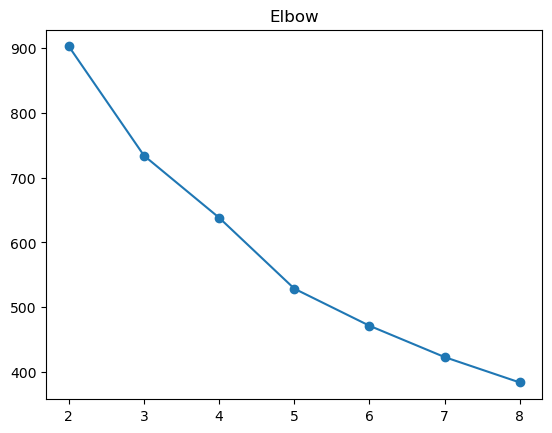

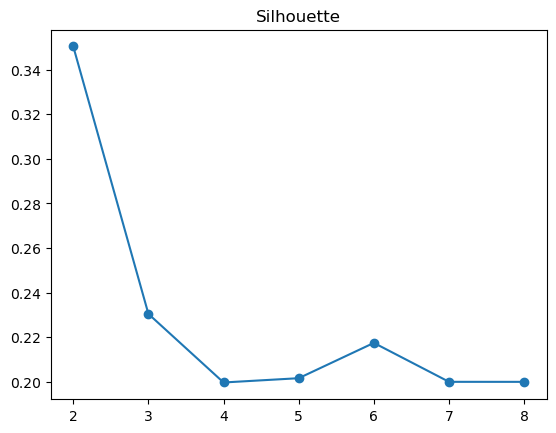

silhouette scores: {2: 0.35043844689886566, 3: 0.23043088783835405, 4: 0.19967255275820148, 5: 0.20159245966902062, 6: 0.21743644089906797, 7: 0.1999639734768836, 8: 0.19995333739364926}


In [71]:
# standard pre-processing and clustering
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# impute with median
num_feats = [c for c in cluster_df.columns if c!="LocationDesc"]
imp = SimpleImputer(strategy="median")
X = imp.fit_transform(cluster_df[num_feats])

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to reduce noise (optional)
pca = PCA(n_components=0.90, svd_solver="full")  # keep 90% variance
X_pca = pca.fit_transform(X_scaled)
print("PCA components:", X_pca.shape[1])

# elbow & silhouette
inertia, sil = [], []
K = range(2,9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_pca)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_pca, km.labels_))

plt.figure(); plt.plot(K, inertia, '-o'); plt.title("Elbow"); plt.show()
plt.figure(); plt.plot(K, sil, '-o'); plt.title("Silhouette"); plt.show()
print("silhouette scores:", dict(zip(K, sil)))

In [73]:

# Now compute cluster summary from the original features (safe and interpretable)
num_feats = [c for c in cluster_df.columns if c not in ("LocationDesc", "Cluster")]
cluster_summary = cluster_df.groupby("Cluster")[num_feats].mean()
print(cluster_summary.T)   # transpose for easier reading (features down, clusters across)

Cluster                                                     0          1
Consumed_vegetables_less_than_one_time_daily_am...  12.913636   8.194444
Consumed_regular_soda_at_least_one_time_daily_a...  22.945455  14.151515
Gestational_diabetes_among_women_with_a_recent_...   9.665000  10.651905
Consumed_fruit_less_than_one_time_daily_among_h...  10.995833   7.616667
Obesity_among_high_school_students                  19.041667  15.295946
Met_aerobic_physical_activity_guideline_among_h...  22.800000  22.891892
Children_and_adolescents_aged_6_13_years_meetin...  26.995455  26.413750
Infants_who_were_exclusively_breastfed_through_...  22.183333  27.458750
Infants_who_were_breastfed_at_12_months             28.987500  39.677500
Met_aerobic_physical_activity_guideline_for_sub...  43.625000  53.090000
Cervical_cancer_screening_among_women_aged_21_6...  83.312500  82.847561
Current_smoking_among_adults_with_chronic_obstr...  40.465278  36.063415
Taking_medicine_to_control_high_blood_pressure_... 

In [74]:
cluster_df[cluster_df["Cluster"] == 0]["LocationDesc"]

0            Alabama
3           Arkansas
10           Georgia
15           Indiana
18          Kentucky
19         Louisiana
25       Mississippi
37          Oklahoma
40       Puerto Rico
42    South Carolina
44         Tennessee
51     West Virginia
Name: LocationDesc, dtype: object

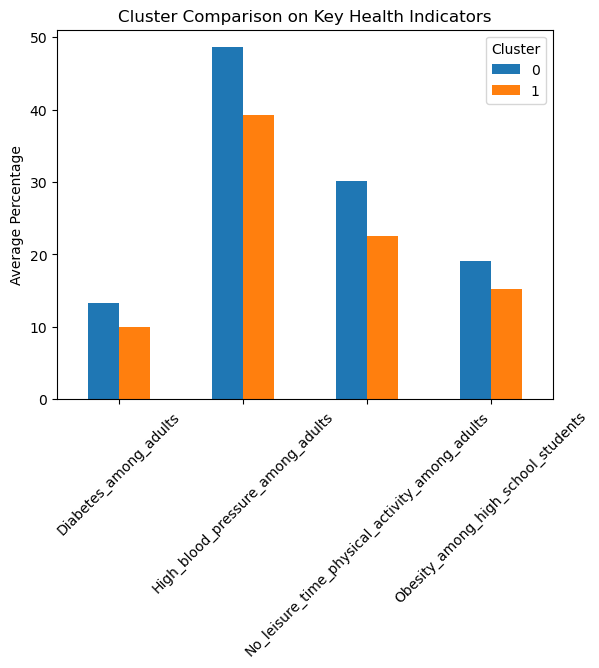

In [79]:
cluster_summary = cluster_df.groupby("Cluster")[num_feats].mean()

# Select a few key indicators
important = [
    "Diabetes_among_adults",
    "High_blood_pressure_among_adults",
    "No_leisure_time_physical_activity_among_adults",
    "Obesity_among_high_school_students"
]

cluster_summary[important].T.plot(kind="bar")
plt.title("Cluster Comparison on Key Health Indicators")
plt.ylabel("Average Percentage")
plt.xticks(rotation=45)
plt.show()

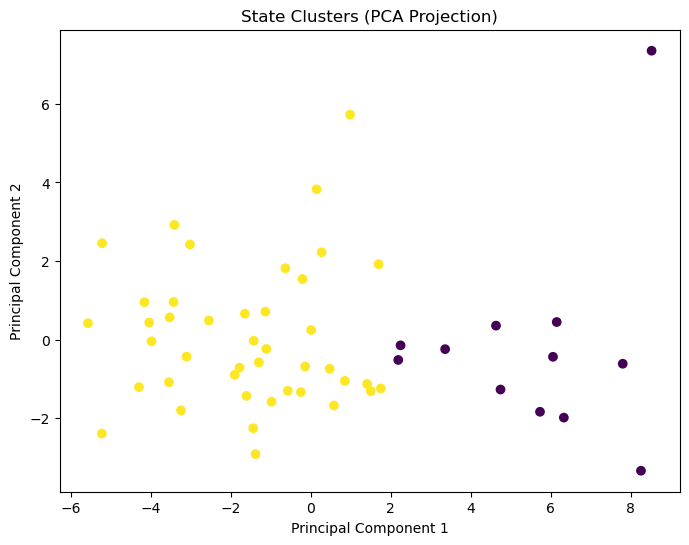

In [80]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=cluster_df["Cluster"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("State Clusters (PCA Projection)")
plt.show()

In [81]:
high_risk_cluster = 0  # change if needed

high_risk_states = cluster_df[cluster_df["Cluster"] == high_risk_cluster]["LocationDesc"]

print("High-Risk States:")
print(high_risk_states.tolist())

High-Risk States:
['Alabama', 'Arkansas', 'Georgia', 'Indiana', 'Kentucky', 'Louisiana', 'Mississippi', 'Oklahoma', 'Puerto Rico', 'South Carolina', 'Tennessee', 'West Virginia']


### High-Risk Vs Low-Risk States

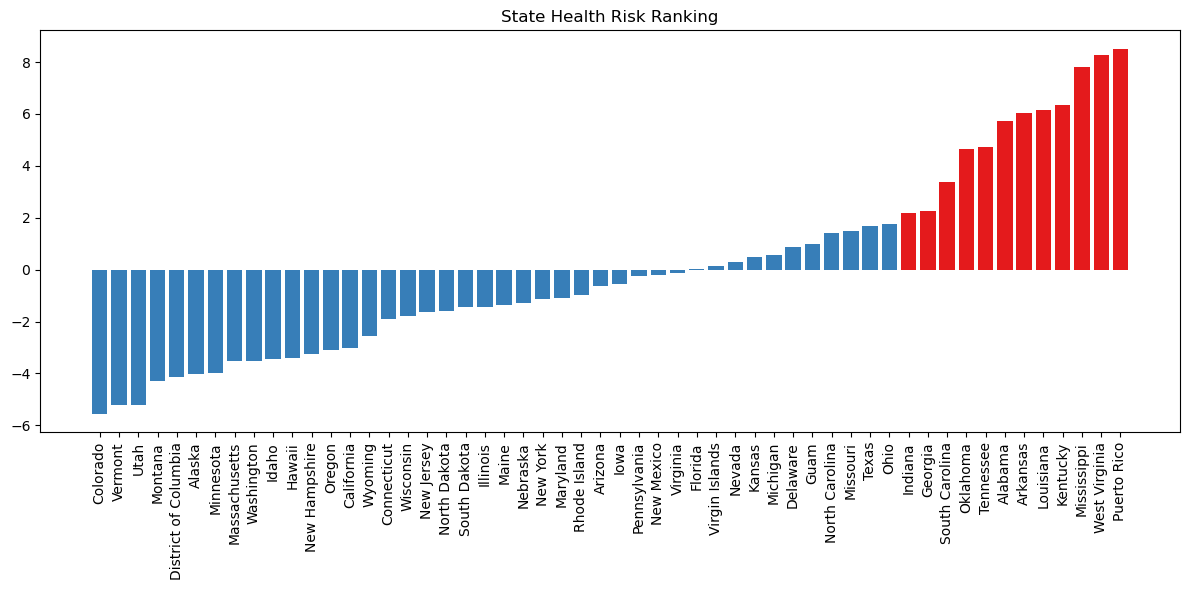

In [85]:
plt.figure(figsize=(12,6))

cluster_df_sorted = cluster_df.sort_values("PC1")

plt.bar(cluster_df_sorted["LocationDesc"],
        cluster_df_sorted["PC1"],
        color=plt.cm.Set1(cluster_df_sorted["Cluster"]))

plt.xticks(rotation=90)
plt.title("State Health Risk Ranking")
plt.tight_layout()
plt.show()

### Show Only Top & Bottom 10

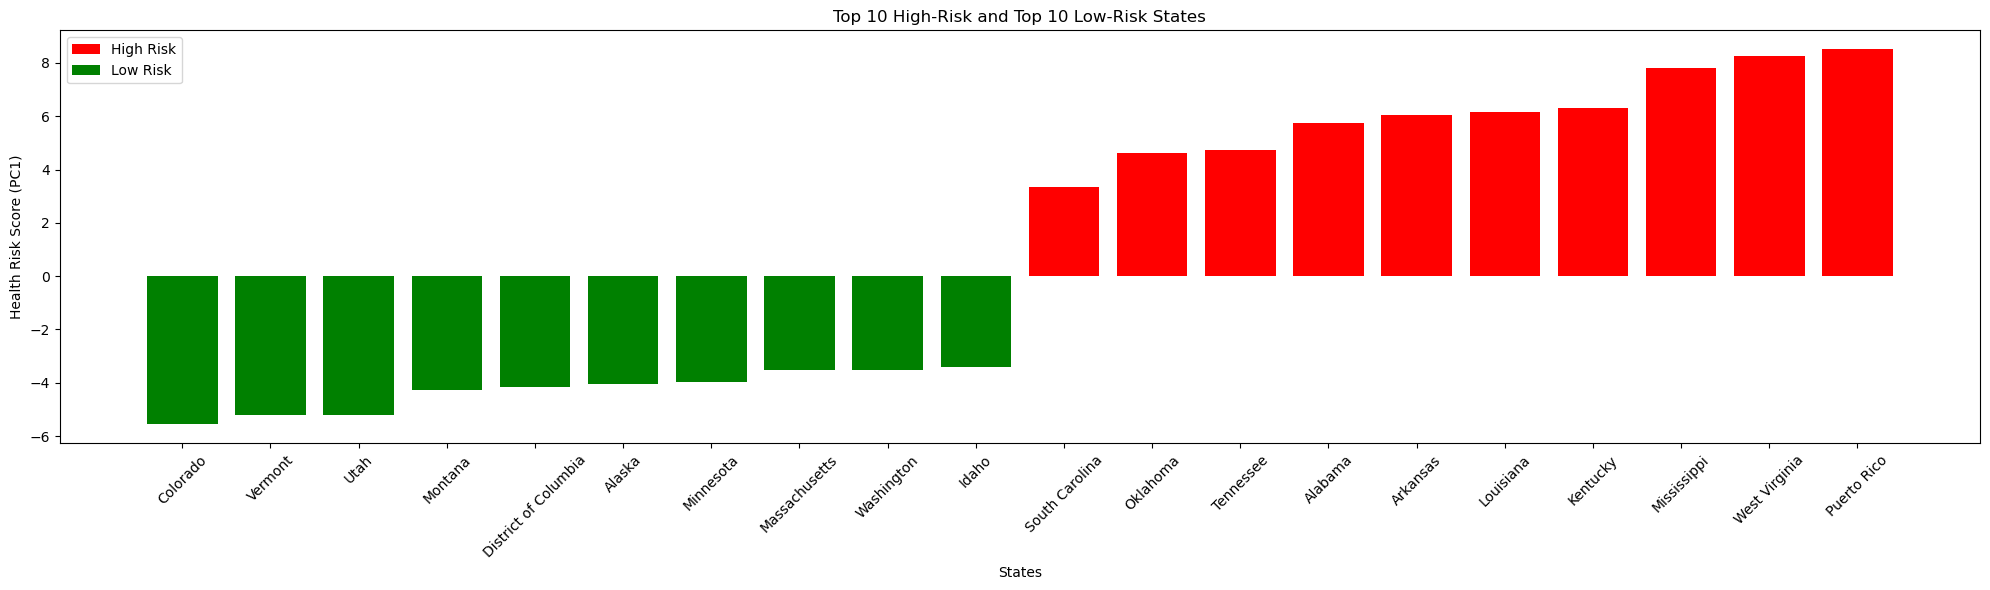

In [90]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='red', label='High Risk'),
    Patch(facecolor='green', label='Low Risk')
]

# Top 10 high-risk
top10 = cluster_df.sort_values("PC1", ascending=False).head(10)

# Bottom 10 low-risk
bottom10 = cluster_df.sort_values("PC1").head(10)

combined = pd.concat([top10, bottom10])

# Sort combined for better visual order
combined = combined.sort_values("PC1")

# Map cluster numbers to colors
color_map = {0: "red", 1: "green"}
colors = combined["Cluster"].map(color_map)

plt.figure(figsize=(20,6))
plt.bar(combined["LocationDesc"],
        combined["PC1"],
        color=colors)

plt.xticks(rotation=45)
plt.xlabel("States")
plt.ylabel("Health Risk Score (PC1)")
plt.title("Top 10 High-Risk and Top 10 Low-Risk States")

plt.tight_layout()

plt.legend(handles=legend_elements)

plt.show()

 <----------------------------------------- End of our First Exploratory Analysis ---------------------------------------->

#### ----- Regression Analysis Begins -----------

In [106]:
df_cleaned_data["DataValueUnit"].value_counts()

DataValueUnit
%                      203382
Number                  54104
cases per 100,000       31980
per 100,000             11680
cases per 1,000          7488
Years                     312
gallons                   165
cases per 1,000,000       104
Name: count, dtype: int64

In [107]:
df_reg = df_cleaned_data.copy()

# Keep percent and rate-based indicators
df_reg = df_reg[
    df_reg["DataValueUnit"].isin(["%", "cases per 100,000", "per 100,000"])
].copy()

In [108]:
wide_reg = df_reg.pivot_table(
    index=["LocationDesc", "YearStart"],
    columns="Question",
    values="DataValue"
).reset_index()

wide_reg.columns = wide_reg.columns.str.replace(" ", "_")

In [109]:
state_reg = wide_reg.groupby("LocationDesc").mean(numeric_only=True).reset_index()

In [110]:
[col for col in state_reg.columns if "coronary" in col.lower()]

['Coronary_heart_disease_mortality_among_all_people,_underlying_cause']

In [111]:
target = "Coronary_heart_disease_mortality_among_all_people,_underlying_cause"

In [112]:
print(target in state_reg.columns)

True


In [113]:
predictors = [
    "Diabetes_among_adults",
    "High_blood_pressure_among_adults",
    "Current_smoking_among_adults",
    "No_leisure_time_physical_activity_among_adults",
    "High_cholesterol_among_adults_who_have_been_screened"
]

In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X = state_reg[predictors]
y = state_reg[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

KeyError: "['Current_smoking_among_adults', 'No_leisure_time_physical_activity_among_adults'] not in index"